(11058, 8)
         date       city        state  petrol_price_inr_per_litre  \
0  2021-05-01      Delhi        Delhi                       90.40   
1  2021-05-01     Mumbai  Maharashtra                       96.83   
2  2021-05-01    Chennai   Tamil Nadu                       92.43   
3  2021-05-01    Kolkata  West Bengal                       90.62   
4  2021-05-01  Bengaluru    Karnataka                       93.43   

   diesel_price_inr_per_litre  state_vat_petrol_pct  state_vat_diesel_pct  \
0                       80.73                 19.40                 16.75   
1                       87.81                 25.00                 21.00   
2                       85.75                 15.00                 11.00   
3                       83.61                 25.00                 17.00   
4                       85.60                 29.84                 18.40   

   is_long_freeze  
0               0  
1               0  
2               0  
3               0  
4          

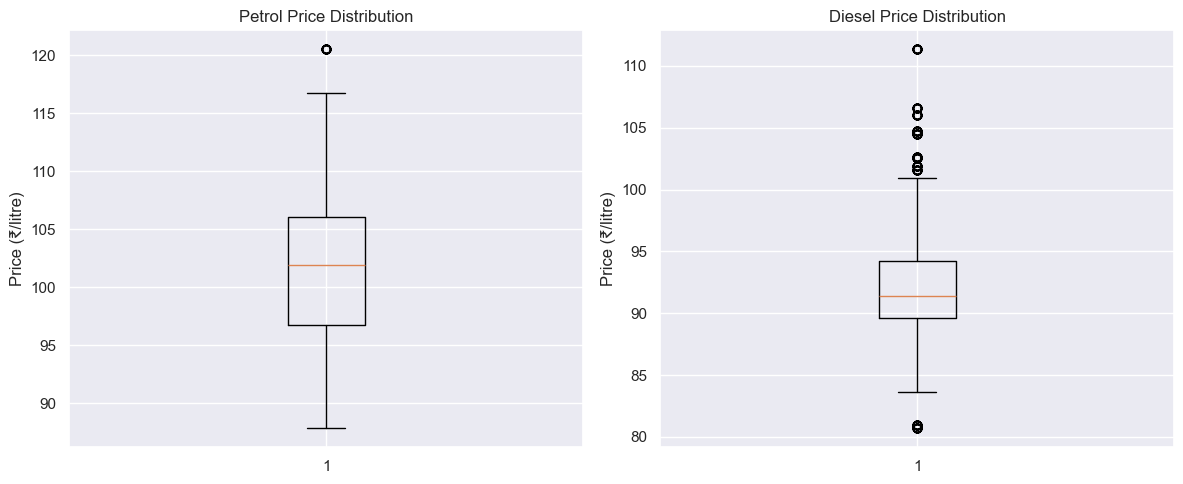

petrol_price_inr_per_litre: 31 outliers detected
diesel_price_inr_per_litre: 333 outliers detected
Cleaned dataset shape: (11058, 12)
date                          datetime64[ns]
city                                category
state                               category
petrol_price_inr_per_litre           float64
diesel_price_inr_per_litre           float64
state_vat_petrol_pct                 float64
state_vat_diesel_pct                 float64
is_long_freeze                          bool
year                                   int32
month                                  int32
month_name                            object
price_diff                           float64
dtype: object
Cleaned dataset saved!
petrol_price_inr_per_litre:
  IQR Range: ₹82.75 - ₹120.00
  Outliers detected: 31 rows
  These are RETAINED as they represent real price events

diesel_price_inr_per_litre:
  IQR Range: ₹82.69 - ₹101.17
  Outliers detected: 333 rows
  These are RETAINED as they represent real price events

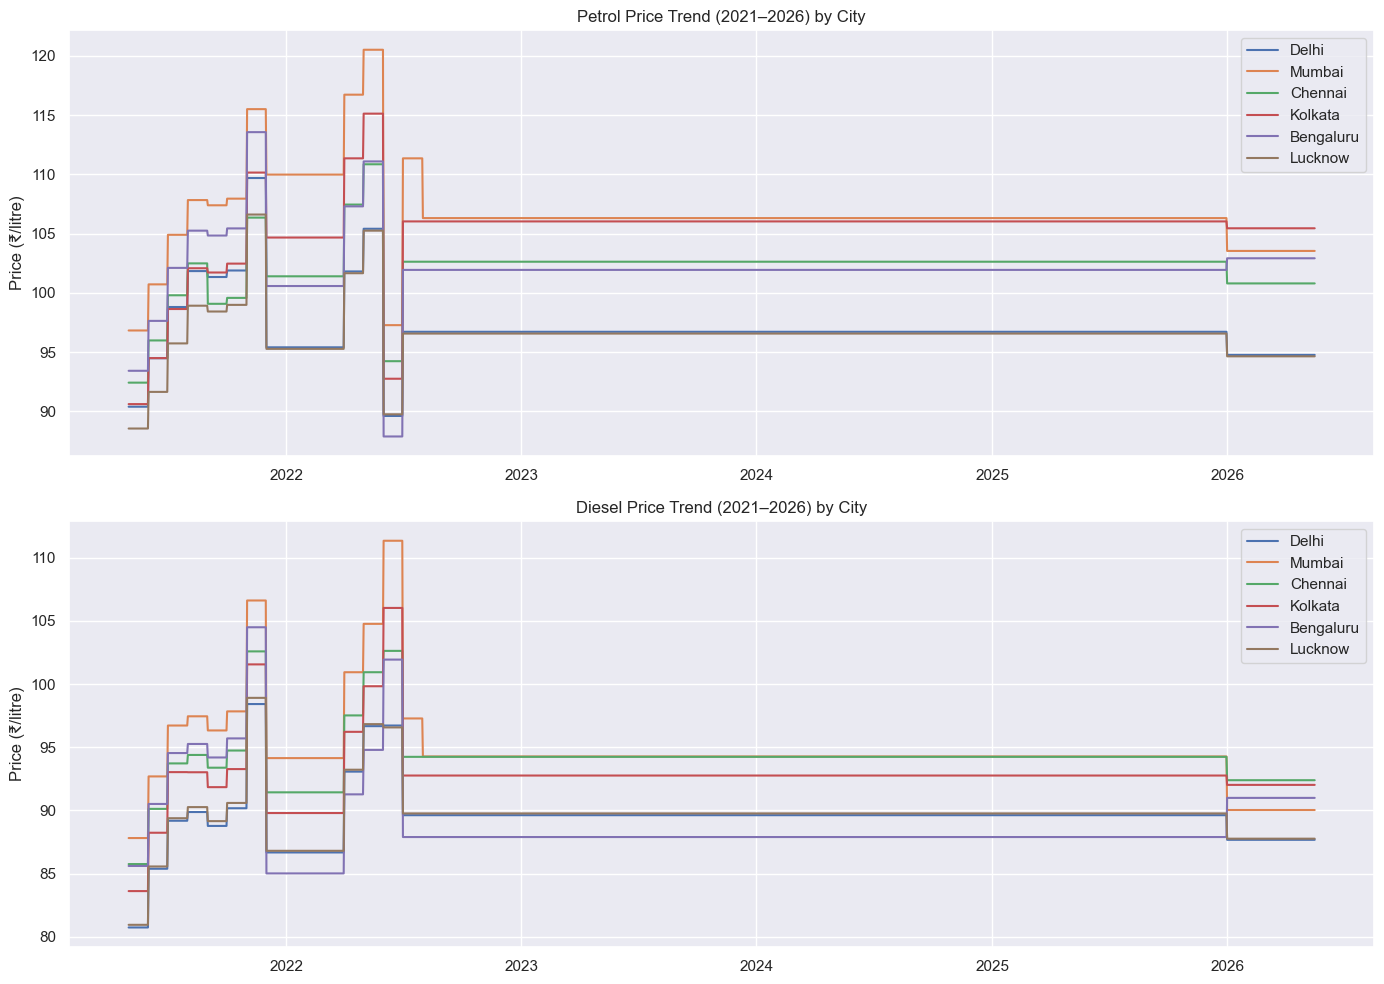

C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:126: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_avg = df.groupby('city')[['petrol_price_inr_per_litre', 'diesel_price_inr_per_litre']].mean().reset_index()


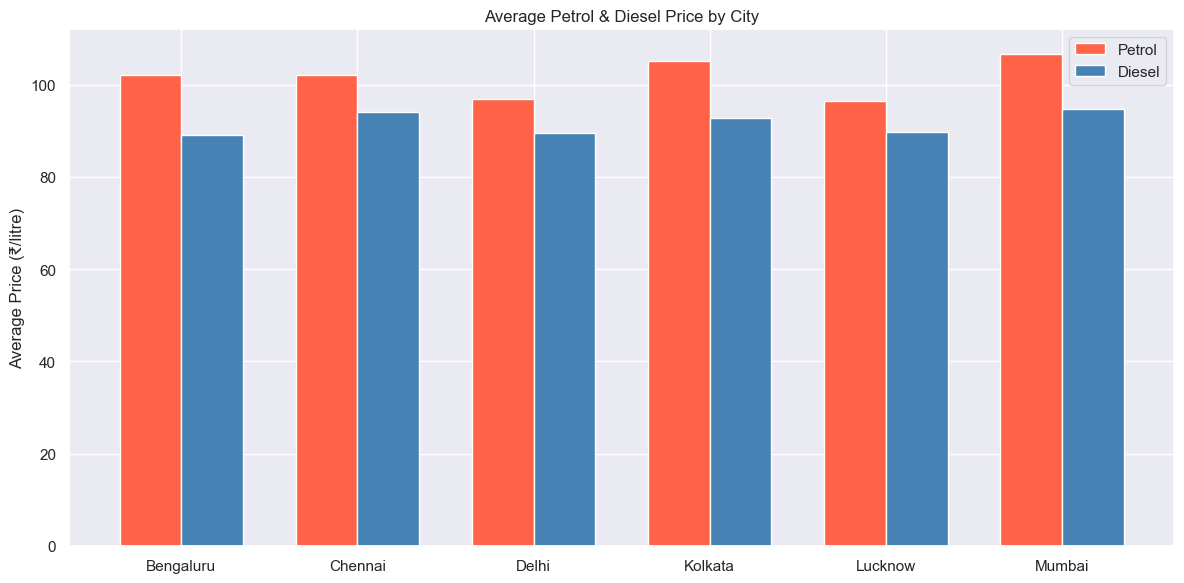

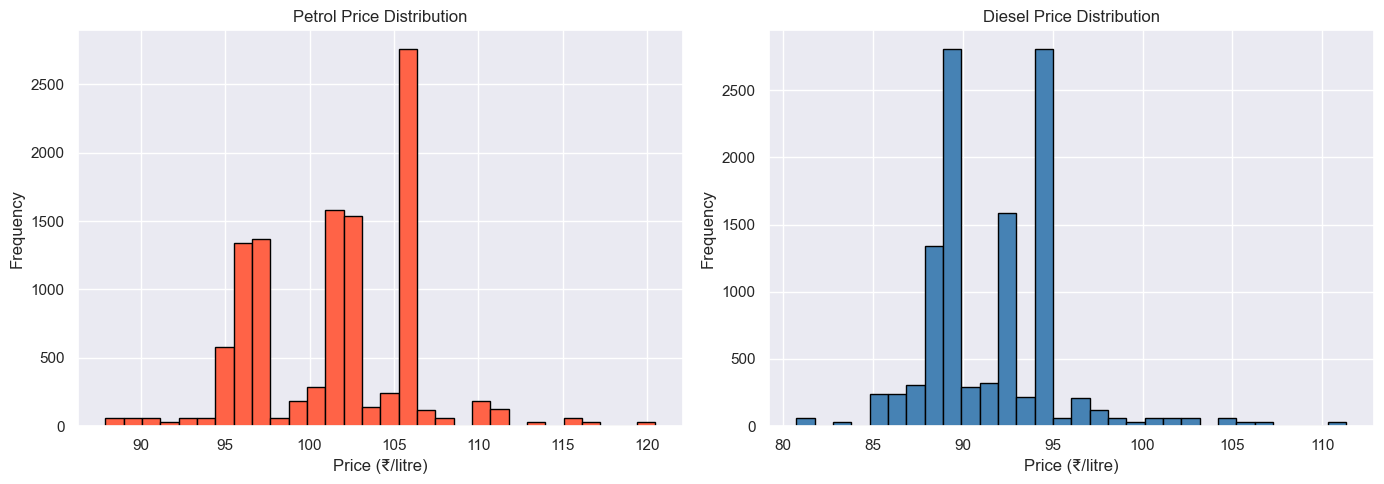

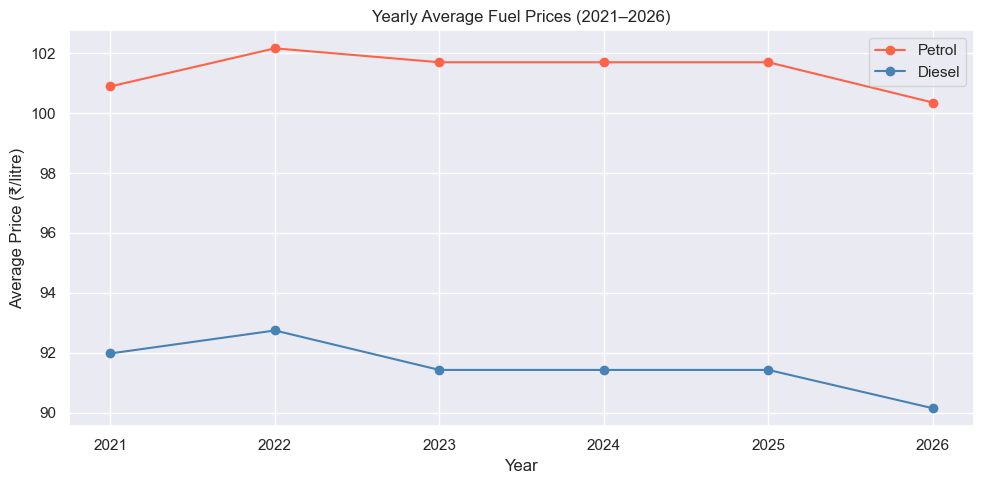

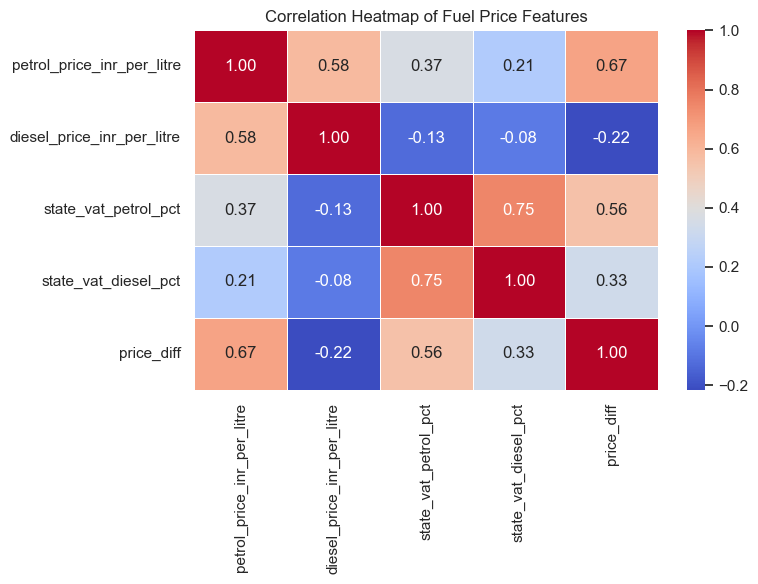

C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='petrol_price_inr_per_litre', palette='Reds', ax=axes[0])
C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='diesel_price_inr_per_litre', palette='Blues', ax=axes[1])


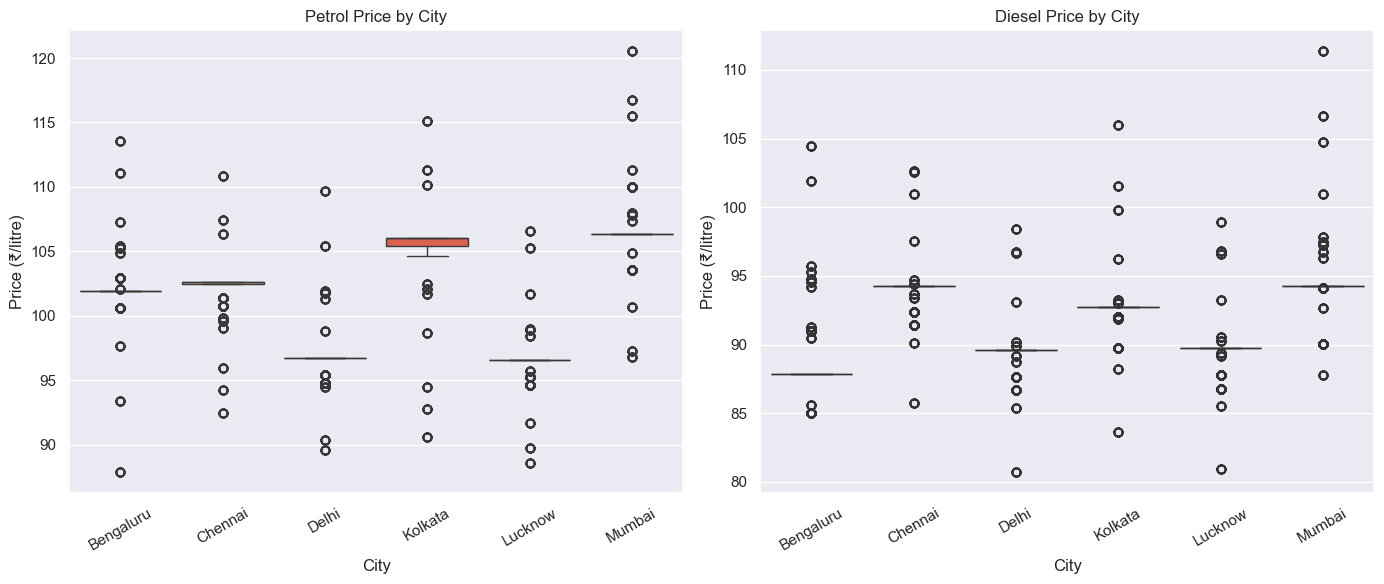

C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_long_freeze', y='petrol_price_inr_per_litre',
C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:210: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Frozen', 'Long Freeze'])
C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:213: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_long_freeze', y='diesel_price_inr_per_litre',
C:\Users\uditk\AppData\Local\Temp\ipykernel_29880\3121175081.py:216: UserWarning: set_tickla

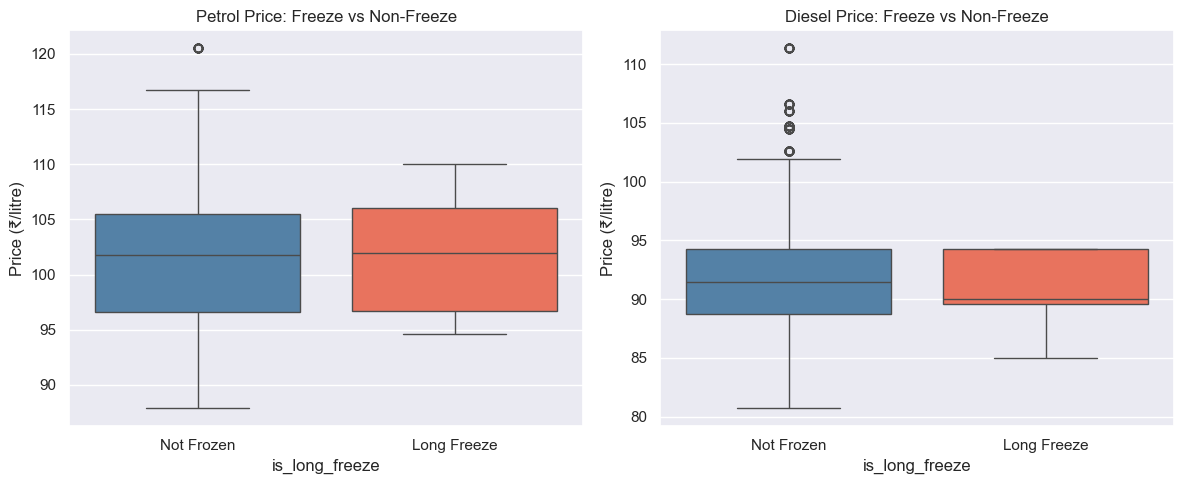

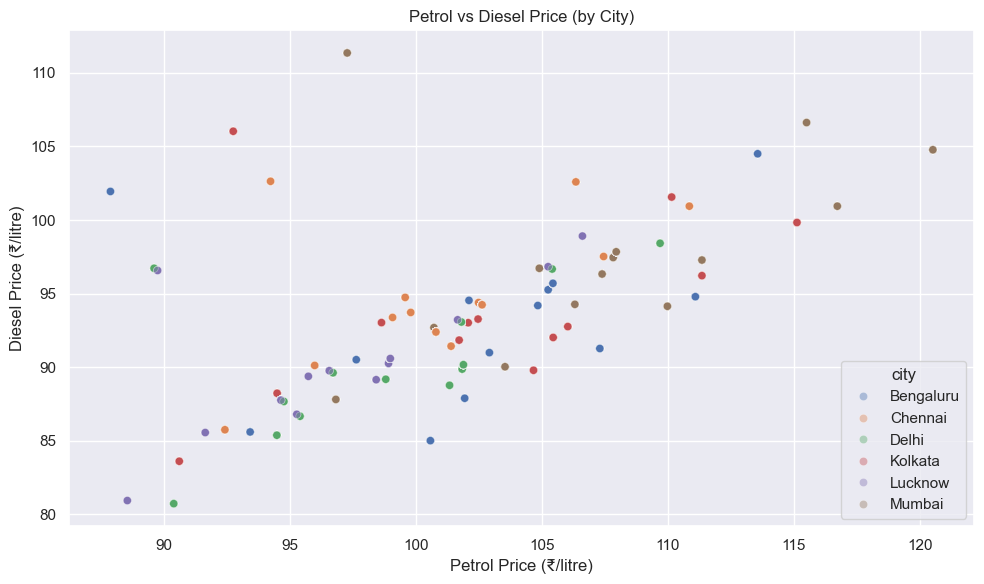

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#Loading dataset
df = pd.read_csv(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\india_fuel_prices_daily.csv")

print(df.shape)
print(df.head())

#Checking data types
print(df.dtypes)

#Check for missing values
print(df.isnull().sum())

#Check for duplicates
print("Duplicates:" , df.duplicated().sum())

#Summary statistics
print(df.describe())

#Convert 'date' from string to datetime
df['date'] = pd.to_datetime(df['date'])

#Converting categorical columns
df['city'] = df['city'].astype('category')
df['state'] = df['state'].astype('category')
df['is_long_freeze'] = df['is_long_freeze'].astype(bool)

print(df.dtypes)

#Extract time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

#Price difference between petrol and diesel
df['price_diff'] = df['petrol_price_inr_per_litre'] - df['diesel_price_inr_per_litre']

print(df[['date', 'year', 'month', 'price_diff']].head())

# Box plots to visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['petrol_price_inr_per_litre'])
axes[0].set_title('Petrol Price Distribution')
axes[0].set_ylabel('Price (₹/litre)')

axes[1].boxplot(df['diesel_price_inr_per_litre'])
axes[1].set_title('Diesel Price Distribution')
axes[1].set_ylabel('Price (₹/litre)')

plt.tight_layout()
plt.savefig('outlier_check.png', dpi=150)
plt.show()

# IQR method to flag outliers
for col in ['petrol_price_inr_per_litre', 'diesel_price_inr_per_litre']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

# Confirm final shape and save
print("Cleaned dataset shape:", df.shape)
print(df.dtypes)

# Save cleaned version
df.to_csv("india_fuel_prices_cleaned.csv", index=False)
print("Cleaned dataset saved!")

# Outlier Analysis using IQR
for col in ['petrol_price_inr_per_litre', 'diesel_price_inr_per_litre']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}:")
    print(f"  IQR Range: ₹{lower:.2f} - ₹{upper:.2f}")
    print(f"  Outliers detected: {len(outliers)} rows")
    print(f"  These are RETAINED as they represent real price events\n")

# Add derived features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['price_diff'] = df['petrol_price_inr_per_litre'] - df['diesel_price_inr_per_litre']

print("Derived features added!")
print(df[['date', 'year', 'month', 'price_diff']].head())

df.to_csv(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\india_fuel_prices_cleaned.csv", index=False)
print("Cleaned dataset saved!")
print("Final shape:", df.shape)
print(df.dtypes)

# Set the visual style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    axes[0].plot(city_data['date'], city_data['petrol_price_inr_per_litre'], label=city)
    axes[1].plot(city_data['date'], city_data['diesel_price_inr_per_litre'], label=city)

axes[0].set_title('Petrol Price Trend (2021–2026) by City')
axes[0].set_ylabel('Price (₹/litre)')
axes[0].legend()

axes[1].set_title('Diesel Price Trend (2021–2026) by City')
axes[1].set_ylabel('Price (₹/litre)')
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot1_price_trend.png", dpi=150)
plt.show()

city_avg = df.groupby('city')[['petrol_price_inr_per_litre', 'diesel_price_inr_per_litre']].mean().reset_index()

x = range(len(city_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width/2 for i in x], city_avg['petrol_price_inr_per_litre'], width, label='Petrol', color='tomato')
ax.bar([i + width/2 for i in x], city_avg['diesel_price_inr_per_litre'], width, label='Diesel', color='steelblue')

ax.set_xticks(list(x))
ax.set_xticklabels(city_avg['city'])
ax.set_title('Average Petrol & Diesel Price by City')
ax.set_ylabel('Average Price (₹/litre)')
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot2_city_avg.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['petrol_price_inr_per_litre'], bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Petrol Price Distribution')
axes[0].set_xlabel('Price (₹/litre)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['diesel_price_inr_per_litre'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Diesel Price Distribution')
axes[1].set_xlabel('Price (₹/litre)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot3_distribution.png", dpi=150)
plt.show()

yearly = df.groupby('year')[['petrol_price_inr_per_litre', 'diesel_price_inr_per_litre']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['petrol_price_inr_per_litre'], marker='o', color='tomato', label='Petrol')
plt.plot(yearly['year'], yearly['diesel_price_inr_per_litre'], marker='o', color='steelblue', label='Diesel')

plt.title('Yearly Average Fuel Prices (2021–2026)')
plt.xlabel('Year')
plt.ylabel('Average Price (₹/litre)')
plt.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot4_yearly_trend.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
corr = df[['petrol_price_inr_per_litre', 'diesel_price_inr_per_litre',
           'state_vat_petrol_pct', 'state_vat_diesel_pct', 'price_diff']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Fuel Price Features')

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot5_heatmap.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='city', y='petrol_price_inr_per_litre', palette='Reds', ax=axes[0])
axes[0].set_title('Petrol Price by City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Price (₹/litre)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='city', y='diesel_price_inr_per_litre', palette='Blues', ax=axes[1])
axes[1].set_title('Diesel Price by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Price (₹/litre)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot6_boxplot_city.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='is_long_freeze', y='petrol_price_inr_per_litre',
            palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Petrol Price: Freeze vs Non-Freeze')
axes[0].set_xticklabels(['Not Frozen', 'Long Freeze'])
axes[0].set_ylabel('Price (₹/litre)')

sns.boxplot(data=df, x='is_long_freeze', y='diesel_price_inr_per_litre',
            palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Diesel Price: Freeze vs Non-Freeze')
axes[1].set_xticklabels(['Not Frozen', 'Long Freeze'])
axes[1].set_ylabel('Price (₹/litre)')

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot7_freeze.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='petrol_price_inr_per_litre', y='diesel_price_inr_per_litre',
                hue='city', alpha=0.4)

plt.title('Petrol vs Diesel Price (by City)')
plt.xlabel('Petrol Price (₹/litre)')
plt.ylabel('Diesel Price (₹/litre)')

plt.tight_layout()
plt.savefig(r"C:\Users\uditk\OneDrive\Desktop\Petrol dataset\plot8_scatter.png", dpi=150)
plt.show()